<a href="https://colab.research.google.com/github/Godenzo0n/ml_train/blob/develop/week_01_ml_intro/Homework/hw_1_game_of_thrones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 80.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 127MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [200]:
data = pd.read_csv('/content/game_of_thrones_train.csv', index_col = 'S.No')

In [174]:
data.sample(5)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
884,Alekyne Florent,Brightwater,1,NaN,NaN,NaN,NaN,NaN,House Florent,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.066890,1
93,Richard Farrow,Ser,0,NaN,NaN,NaN,NaN,NaN,House Farrow,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.016722,0
768,Melaquin,Maester,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.000000,1
1135,Jonos Stark,King in the North,1,Northmen,NaN,NaN,NaN,NaN,House Stark,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.010033,1
819,Old Crackbones,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0,0.000000,1


In [201]:
numerical_columns = data.select_dtypes(exclude=['object']).columns
categorial_columns = data.select_dtypes(include=['object']).columns

**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [202]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

In [203]:
data[numerical_columns].isnull().sum()


,0
male,0
dateOfBirth,1278
book1,0
book2,0
book3,0
book4,0
book5,0
isAliveMother,1539
isAliveFather,1535
isAliveHeir,1536


In [205]:
data[categorial_columns].isnull().sum()

,0
name,0
title,840
culture,1069
mother,1539
father,1535
heir,1536
house,381
spouse,1357


In [206]:
data[numerical_columns] = data[numerical_columns].fillna(-1) # есть предположение, что пропуск тоже может быть значимым. Обозначу его за -1
data[numerical_columns].isnull().sum()

,0
male,0
dateOfBirth,0
book1,0
book2,0
book3,0
book4,0
book5,0
isAliveMother,0
isAliveFather,0
isAliveHeir,0


In [207]:
data[categorial_columns] = data[categorial_columns].fillna('unknown')

In [208]:
data.isnull().sum().sum()

np.int64(0)

**Задание 1.4.** Создайте новые признаки.
1. Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
2. Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
3. Упростите признак culture, объединив схожие названия в один.


In [209]:
#apply() позволяет применять функцию к каждой строке или столбцу DataFrame и возвращать результат в виде нового DataFrame
data['isPopular'] = data['popularity'].apply(lambda row : 1 if row > 0.5 else 0)
data['boolDeadRelations'] = data['numDeadRelations'].apply(lambda row : 0 if row == 0 else 1)

In [143]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

Text(0.5, 1.0, 'Корреляционная матрица количественных переменных')

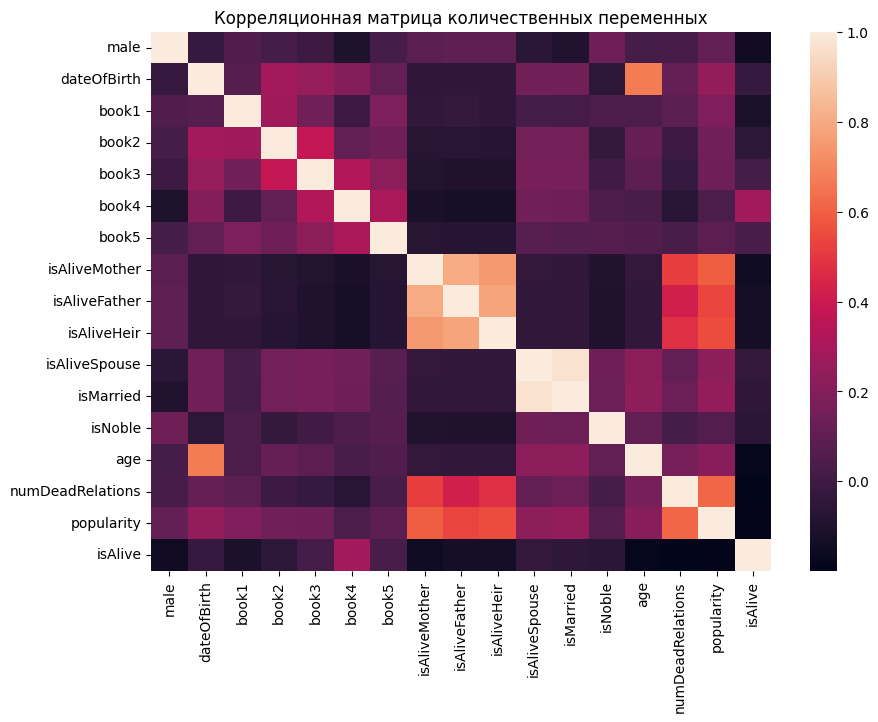

In [210]:
corr_matrix = data[numerical_columns].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix)
plt.title('Корреляционная матрица количественных переменных')

       name_features  importance
9        isAliveHeir    0.005417
8      isAliveFather    0.005544
7      isAliveMother    0.007326
11         isMarried    0.013796
10     isAliveSpouse    0.019121
0               male    0.031893
14  numDeadRelations    0.033696
2              book1    0.036828
3              book2    0.038562
6              book5    0.042723
4              book3    0.043687
12           isNoble    0.049522
1        dateOfBirth    0.073582
5              book4    0.087111
13               age    0.092352
15        popularity    0.418841


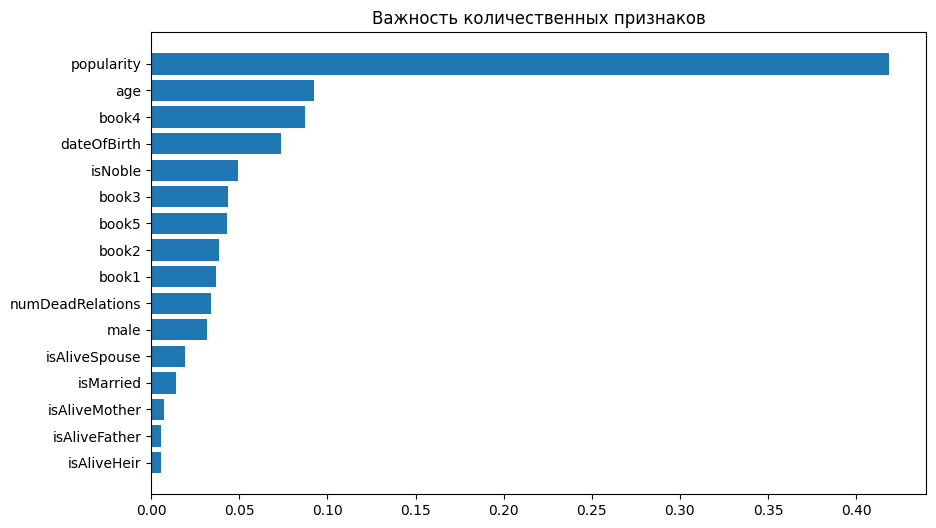

In [211]:
from sklearn.ensemble import RandomForestClassifier

X = data[numerical_columns].drop('isAlive', axis=1)
y = data['isAlive']

model = RandomForestClassifier()
model.fit(X, y)

feature_importance = pd.DataFrame({
    'name_features': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance')

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['name_features'], feature_importance['importance'])
plt.title('Важность количественных признаков')
plt.show()

In [212]:
data.drop(columns=['isAliveMother'], inplace=True)

**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

In [213]:
data['isAlive'].dtypes

dtype('int64')

In [214]:
data['isAlive'].value_counts()

,count
isAlive,
1,1212
0,345


**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [221]:
categorial_columns

Index(['name', 'title', 'culture', 'mother', 'father', 'heir', 'house',
       'spouse'],
      dtype='object')

In [222]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
data_new = encoder.fit_transform(data[categorial_columns].values)

In [223]:
"""
encoder.categories_ содержит все значения категорий
"""
categorial_columns_name = []
for i in range(len(encoder.categories_)):
  for j in range(len(encoder.categories_[i])):
      categorial_columns_name.append(encoder.categories_[i][j])
len(categorial_columns_name)



2366

In [226]:
data_new = pd.DataFrame(data_new.toarray(), columns=categorial_columns_name)
data_new

,Abelar Hightower,Addam,Addam Frey,Addam Marbrand,Addam Osgrey,Addison Hill,Aegon Frey (son of Aenys),Aegon Frey (son of Stevron),Aegon I Targaryen,Aegon II Targaryen,...,Walder Frey,Walter Whent,Walton Frey,Whalen Frey,Wylis Manderly,Wynafrei Whent,Yandry,Ynys Yronwood,Zhoe Blanetree,unknown
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1555,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [241]:
data_new.set_index(data.index, inplace=True)

In [238]:
data = data.drop(categorial_columns, axis=1)

KeyError: "['name', 'title', 'culture', 'mother', 'father', 'heir', 'house', 'spouse'] not found in axis"

In [243]:
data_1 = data.reset_index()
data_2 = data_new.reset_index()
data = pd.concat([data_1, data_2], axis=1)
data.sample(10)

,S.No,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveFather,isAliveHeir,...,Walder Frey,Walter Whent,Walton Frey,Whalen Frey,Wylis Manderly,Wynafrei Whent,Yandry,Ynys Yronwood,Zhoe Blanetree,unknown
283,284,1,-1.0,0,0,0,0,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
161,162,1,-1.0,0,1,1,1,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
53,54,1,-1.0,0,0,0,0,0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
459,460,1,-1.0,0,0,0,1,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
513,514,1,-1.0,0,0,0,1,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1549,1550,1,-1.0,0,1,1,0,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1466,1467,0,289.0,1,1,1,1,1,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
708,709,1,241.0,0,0,0,1,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
364,365,0,-1.0,0,0,1,0,0,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1380,1381,0,-1.0,0,0,0,1,1,-1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [254]:
model = RandomForestClassifier()

X = data.drop('isAlive', axis=1)
y = data['isAlive']

model.fit(X,y)

feature_importance = pd.DataFrame({
  'name_features': X.columns,
  'importance': model.feature_importances_
}).sort_values('importance', ascending = False)




In [256]:
feature_importance.head(20)

,name_features,importance
15,popularity,0.063597
18,S.No,0.057790
0,S.No,0.051297
6,book4,0.037827
13,age,0.032112
2,dateOfBirth,0.022158
2183,Night's Watch,0.014872
1,male,0.012020
3,book1,0.011713
7,book5,0.010679


In [259]:
data = data.drop('S.No', axis=1)

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [260]:
X = data.drop('isAlive', axis=1)
y = data['isAlive']

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [261]:
from sklearn.model_selection import train_test_split

In [262]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=80,train_size=20)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [265]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [266]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [267]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [273]:
# Шаг 1. создание модели
adaboost = AdaBoostClassifier()
rf = RandomForestClassifier(n_estimators=200)
gp = GaussianProcessClassifier()
nb = GaussianNB()
knn = KNeighborsClassifier()
svc = SVC()
dtc = DecisionTreeClassifier()

# Шаг 2. обучение модели
adaboost.fit(X_train, y_train)
rf.fit(X_train, y_train)
gp.fit(X_train, y_train)
nb.fit(X_train, y_train)
knn.fit(X_train, y_train)
svc.fit(X_train, y_train)
dtc.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_hat_adaboost = adaboost.predict(X_test)
y_hat_rf = rf.predict(X_test)
y_hat_gp = gp.predict(X_test)
y_hat_nb = nb.predict(X_test)
y_hat_knn = knn.predict(X_test)
y_hat_svc = svc.predict(X_test)
y_hat_dtc = dtc.predict(X_test)


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [269]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [274]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
print(classification_report(y_test, y_hat_adaboost))
print(classification_report(y_test, y_hat_dtc))
print(classification_report(y_test, y_hat_gp))
print(classification_report(y_test, y_hat_knn))
print(classification_report(y_test, y_hat_nb))
print(classification_report(y_test, y_hat_rf))
print("Accuracy : %.4f" % accuracy)

              precision    recall  f1-score   support

           0       0.71      0.36      0.48        14
           1       0.88      0.97      0.92        66

    accuracy                           0.86        80
   macro avg       0.80      0.66      0.70        80
weighted avg       0.85      0.86      0.84        80

              precision    recall  f1-score   support

           0       0.71      0.36      0.48        14
           1       0.88      0.97      0.92        66

    accuracy                           0.86        80
   macro avg       0.80      0.66      0.70        80
weighted avg       0.85      0.86      0.84        80

              precision    recall  f1-score   support

           0       0.62      0.36      0.45        14
           1       0.88      0.95      0.91        66

    accuracy                           0.85        80
   macro avg       0.75      0.66      0.68        80
weighted avg       0.83      0.85      0.83        80

              preci

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [276]:
# Шаг 3. Предсказание на тестовых данных


# Шаг 4. Оценка предсказания по метрике accuracy

print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8625


In [295]:
test_data = pd.read_csv('/content/game_of_thrones_test.csv', index_col='S.No')

num_col = test_data.select_dtypes(exclude='object').columns
cat_col = test_data.select_dtypes(include='object').columns

test_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              389 non-null    object 
 1   title             221 non-null    object 
 2   male              389 non-null    int64  
 3   culture           189 non-null    object 
 4   dateOfBirth       154 non-null    float64
 5   mother            3 non-null      object 
 6   father            4 non-null      object 
 7   heir              2 non-null      object 
 8   house             343 non-null    object 
 9   spouse            76 non-null     object 
 10  book1             389 non-null    int64  
 11  book2             389 non-null    int64  
 12  book3             389 non-null    int64  
 13  book4             389 non-null    int64  
 14  book5             389 non-null    int64  
 15  isAliveMother     3 non-null      float64
 16  isAliveFather     4 non-null      float64
 17

In [296]:
test_data[num_col] = test_data[num_col].fillna(-1)

In [297]:
test_data[cat_col] = test_data[cat_col].fillna('unknown')

In [298]:
test_data.isnull().sum().sum()

np.int64(0)

In [299]:
test_data['isPopular'] = test_data['popularity'].apply(lambda row : 1 if row > 0.5 else 0)
test_data['boolDeadRelations'] = test_data['numDeadRelations'].apply(lambda row : 0 if row == 0 else 1)

In [300]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
test_data_new = encoder.fit_transform(test_data[cat_col].values)

In [301]:
"""
encoder.categories_ содержит все значения категорий
"""
categorial_columns_name = []
for i in range(len(encoder.categories_)):
  for j in range(len(encoder.categories_[i])):
      categorial_columns_name.append(encoder.categories_[i][j])
len(categorial_columns_name)


774

In [281]:
X_test_data = test_data

adaboost.predict(X_test_data)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- culture
- father
- heir
- house
- isAliveMother
- ...
Feature names seen at fit time, yet now missing:
- 1st: unknown2nd: unknown3rd: unknown
- Abelar Hightower
- Acorn Hall
- Addam
- Addam Frey
- ...


Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [275]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 7.16MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)